Clean sheet notebook on wolf 1130 https://ui.adsabs.harvard.edu/abs/2018ApJ...854..145M/abstract

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
import os
import glob
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
import astropy.constants as const
from astropy.modeling import models, fitting
import lightkurve as lk
from scipy.interpolate import interp1d
from astropy.convolution import convolve, Box1DKernel


#matplotlib set up
%matplotlib inline
from matplotlib import rcParams
rcParams["figure.figsize"] = (14, 5)
rcParams["font.size"] = 20

Extracted and corrected spectra, but HASP won't add them. Why? Need to fix DQs to remove slit loss keywords?

In [3]:
path = 'data/reextractions/'
sx1s = glob.glob('{}*fixed_sx1.fits'.format(path))
sx1s

['data/reextractions/o8ru2h020_fixed_sx1.fits',
 'data/reextractions/o8ru2h010_fixed_sx1.fits']

data/reextractions/o8ru2h020_fixed_sx1.fits
G230LB
data/reextractions/o8ru2h010_fixed_sx1.fits
G230LB


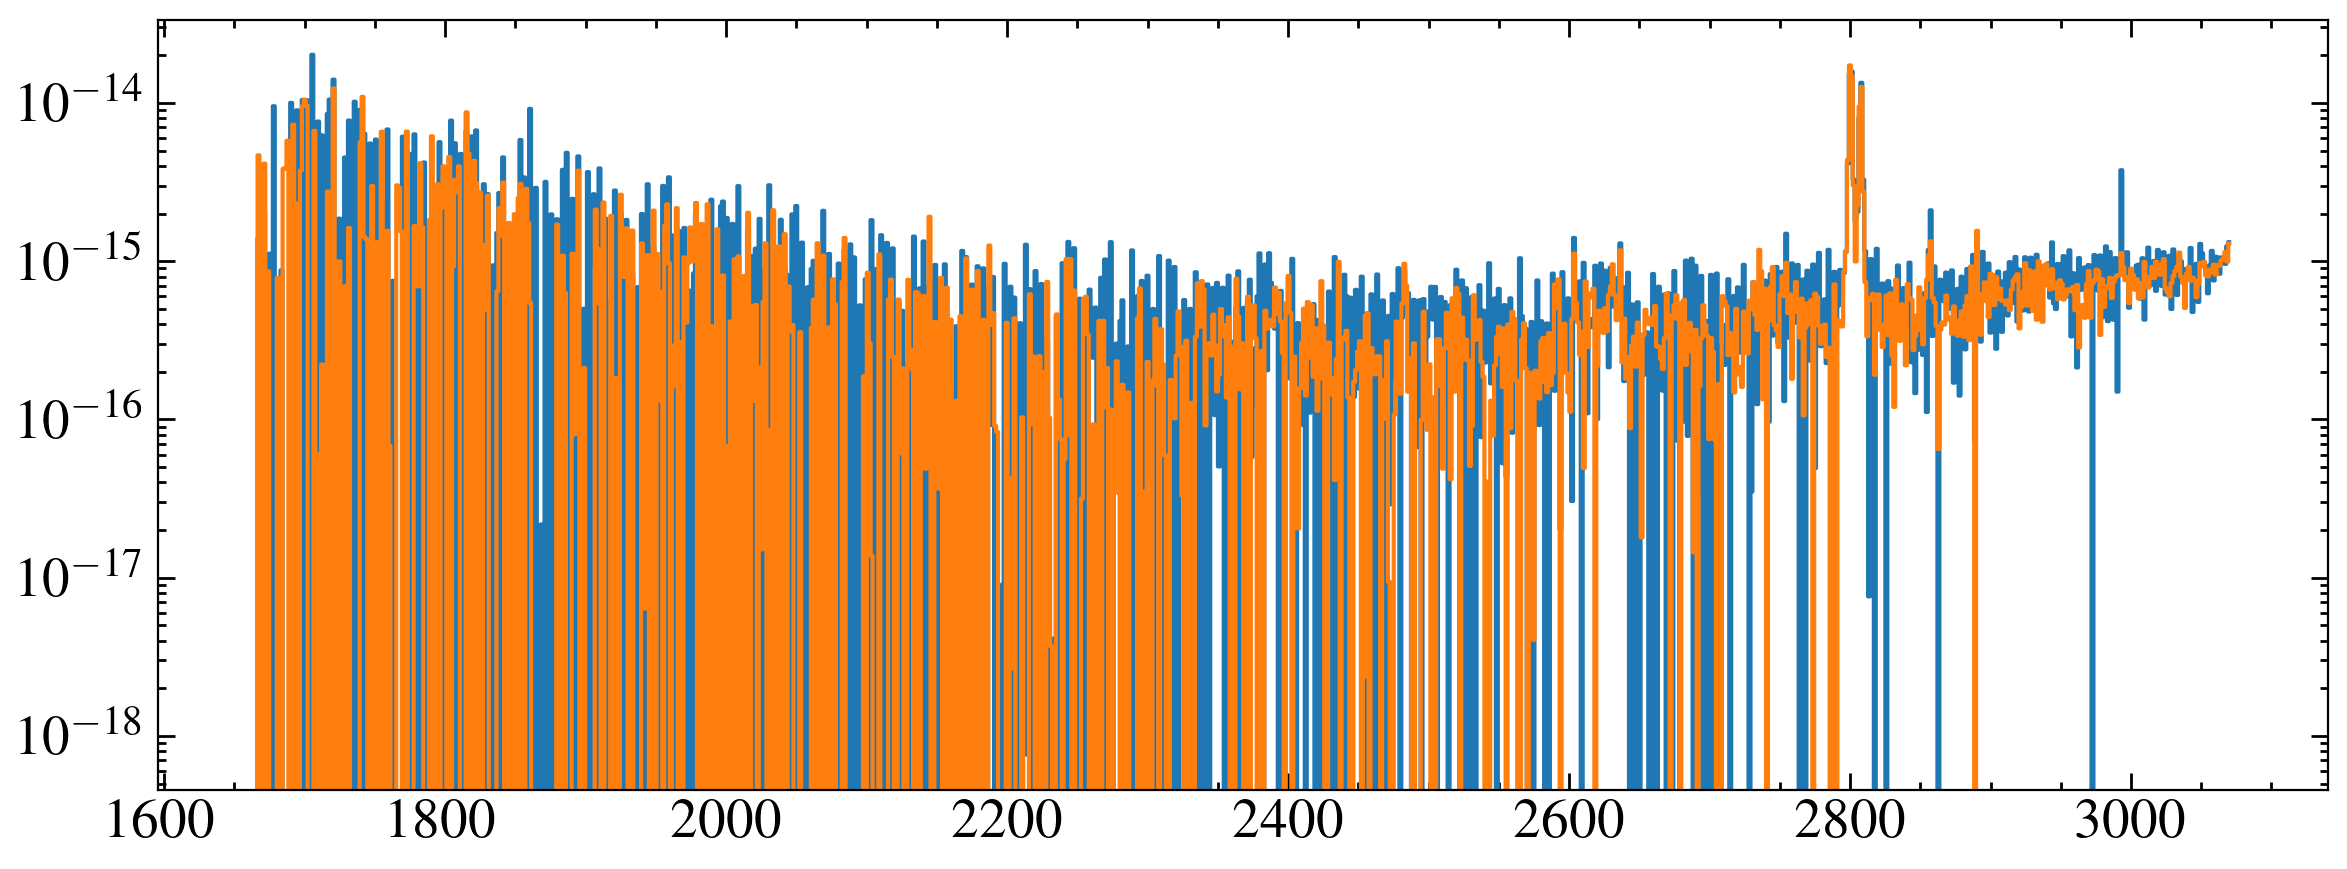

In [8]:
fig, ax = plt.subplots()

for x in sx1s:
    print(x)
    grating = fits.getheader(x, 0)['OPT_ELEM'] 
    print(grating)
    data = fits.getdata(x, 1)[0]
    # print(data['A2Center'])
    w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']

    ax.step(w, f, where='mid')
    # ax.step(w, e, where='mid', alpha=0.5)

    # if grating == 'G230LB':
        # ax.set_ylim(-1e-14, 1e-13)
    # plt.show()
ax.set_yscale('log')


data/reextractions/o8ru2h020_fixed_sx1.fits
NORMAL
G230LB
[2048 2064 2304 2320 2560 2576 3072 3088]
data/reextractions/o8ru2h010_fixed_sx1.fits
NORMAL
G230LB
[2048 2064 2304 2320 2560 2576 3072 3088]


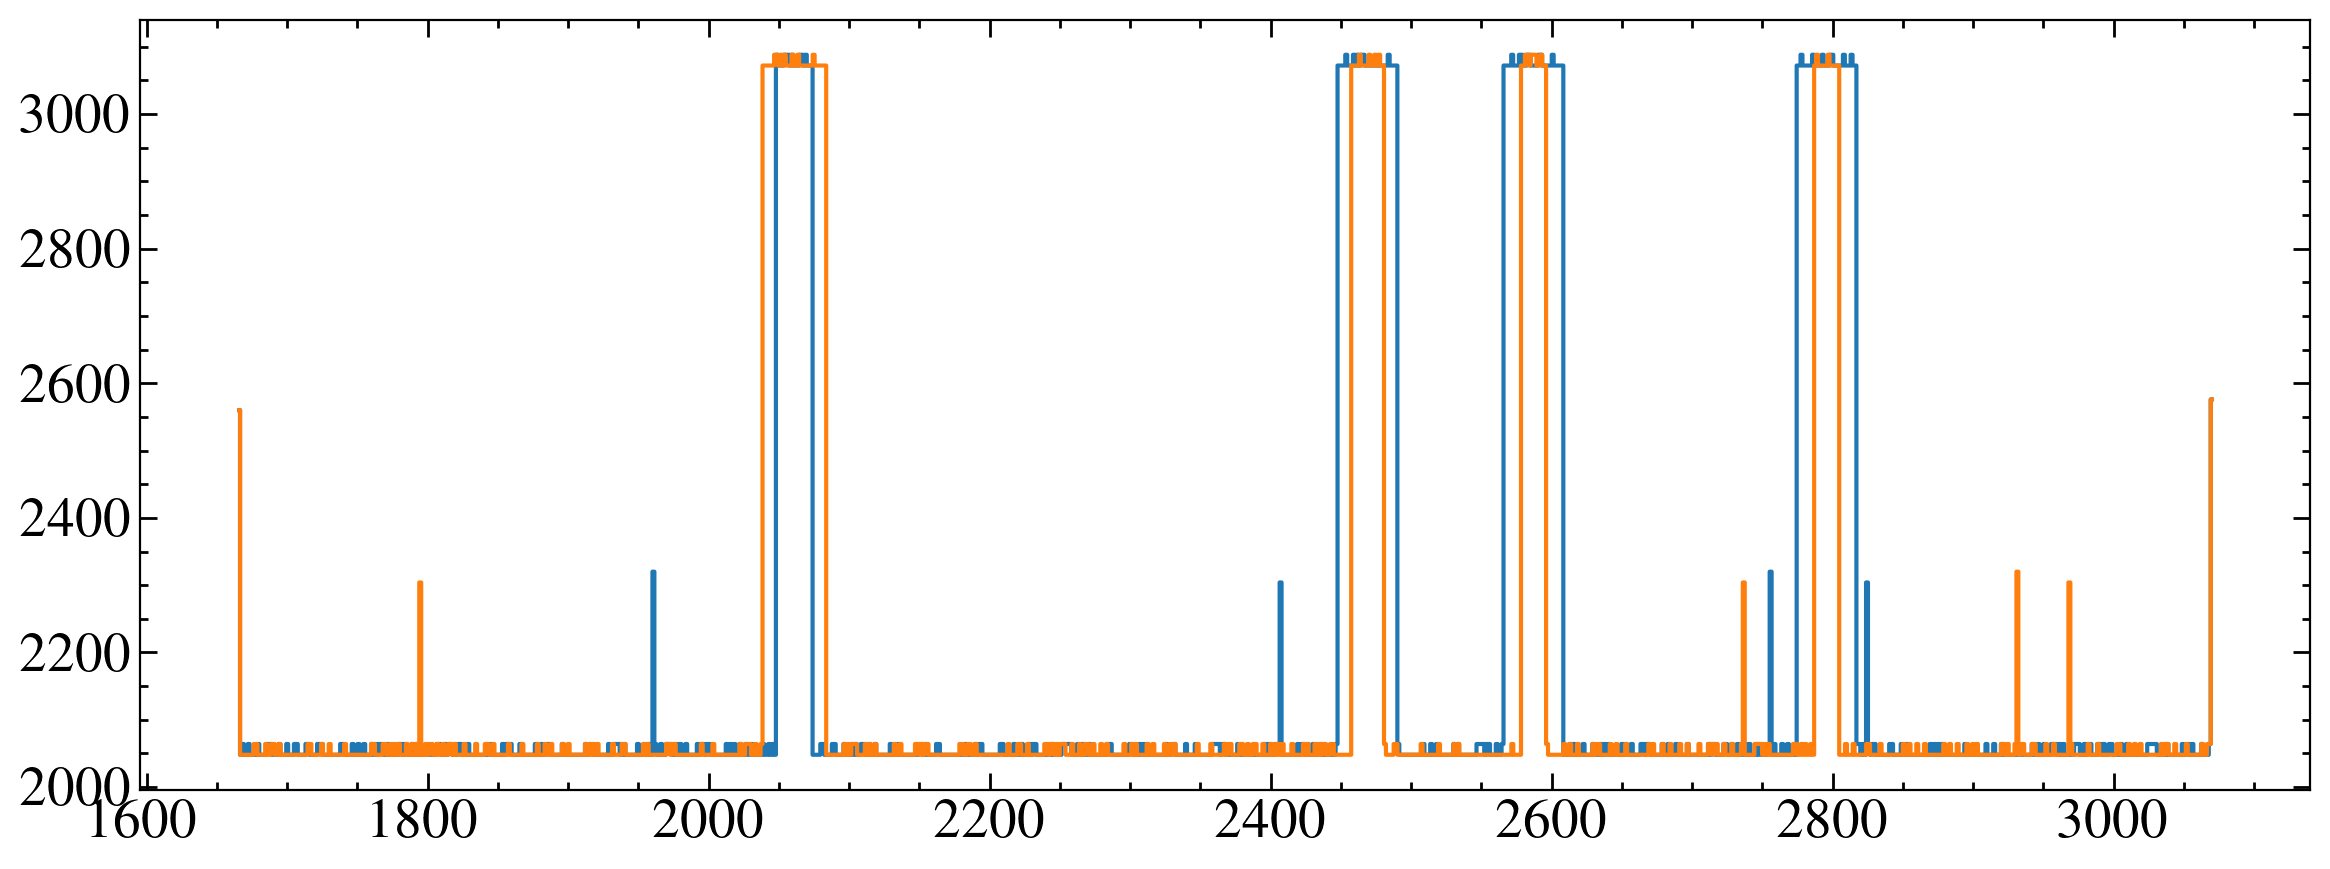

In [14]:
fig, ax = plt.subplots()

for x in sx1s:
    print(x)
    print(fits.getheader(x, 1)['EXPFLAG'])
    grating = fits.getheader(x, 0)['OPT_ELEM'] 
    print(grating)
    data = fits.getdata(x, 1)[0]
    w, f, e, dq= data['WAVELENGTH'], data['FLUX'], data['ERROR'],  data['DQ']

    dqi = np.copy(dq)
    for i in range(len(dqi)):
        if dqi[i] >= 16384:
            dqi[i] -= 16384
    ax.step(w, dqi, where='mid')
    print(np.unique(dqi))

# ax.set_yscale('log')


Just delete all dqs, much easier than mucking around with which ones to keep

In [17]:
for x in sx1s:
    print(x)
    hdul = fits.open(x)
    root = hdul[0].header['ROOTNAME']
    dq = hdul[1].data[0]['DQ']
    # print(len(dq))
    dq = np.zeros(len(dq))
    hdul[1].data[0]['DQ'] = dq
    hdul.writeto('{}hasp/{}_fixed_dqs_sx1.fits'.format(path, root), overwite=True)
    hdul.close()

data/reextractions/o8ru2h020_fixed_sx1.fits
data/reextractions/o8ru2h010_fixed_sx1.fits


In [16]:
path

'data/reextractions/'

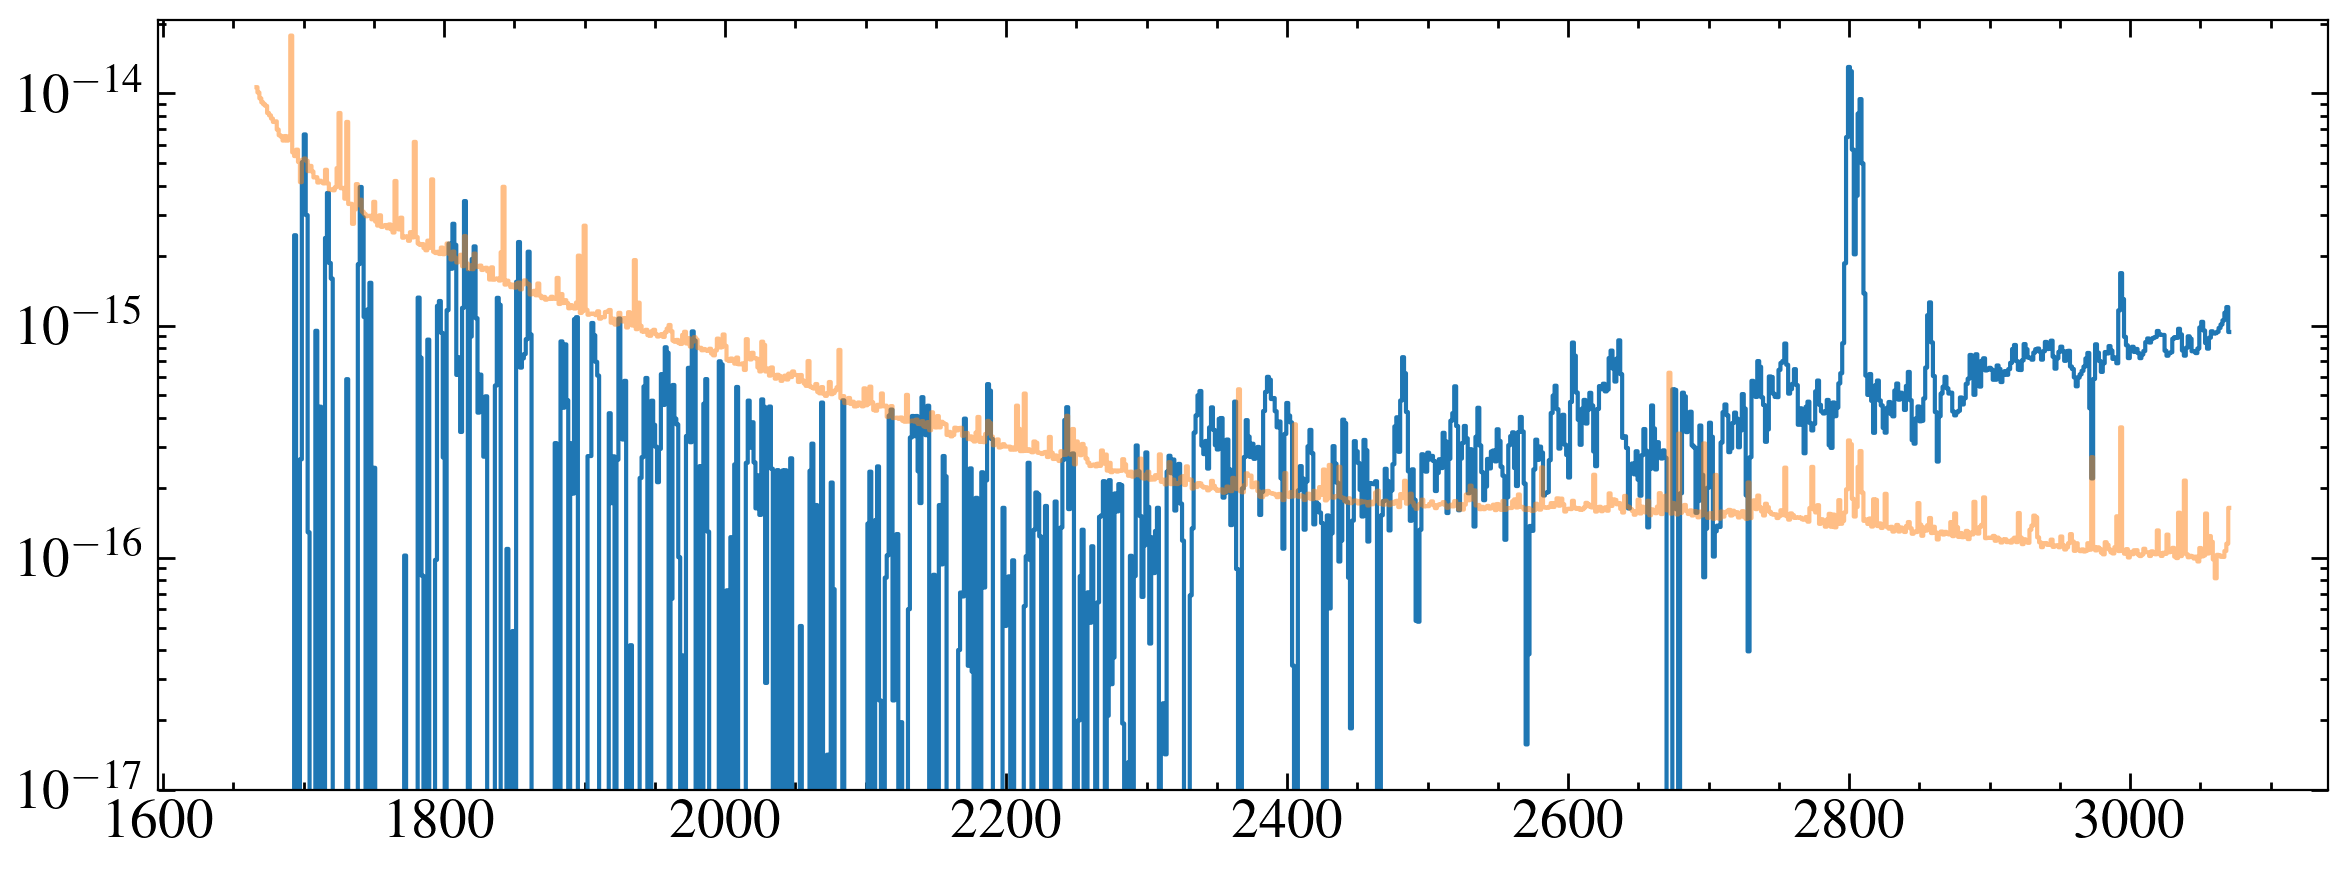

In [32]:
cpath = '/home/david/work/carmenes_binary/data/reextractions/hasp/output/hst_9786_stis_lhs482_g230lb_o8ru_cspec.fits'

fig, ax = plt.subplots()

data = fits.getdata(cpath, 1)[0]
w, f, e= data['WAVELENGTH'], data['FLUX'], data['ERROR']
fi = convolve(f,  Box1DKernel(2))

ax.step(w,fi, where='mid')
ax.step(w,e, where='mid', alpha=0.5)


ax.set_ylim(1e-17)
ax.set_yscale('log')

nw, nf, ne = w, f, e

Stick it onto the lowlib spectrum

In [27]:
lowpath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/wolf1130/hst/hlsp/'
lowdata = fits.getdata('{}hlsp_lowlib_hst_stis_lhs482_g230lb-g430l-g750l_v1.0_spect.fits'.format(lowpath), 1)

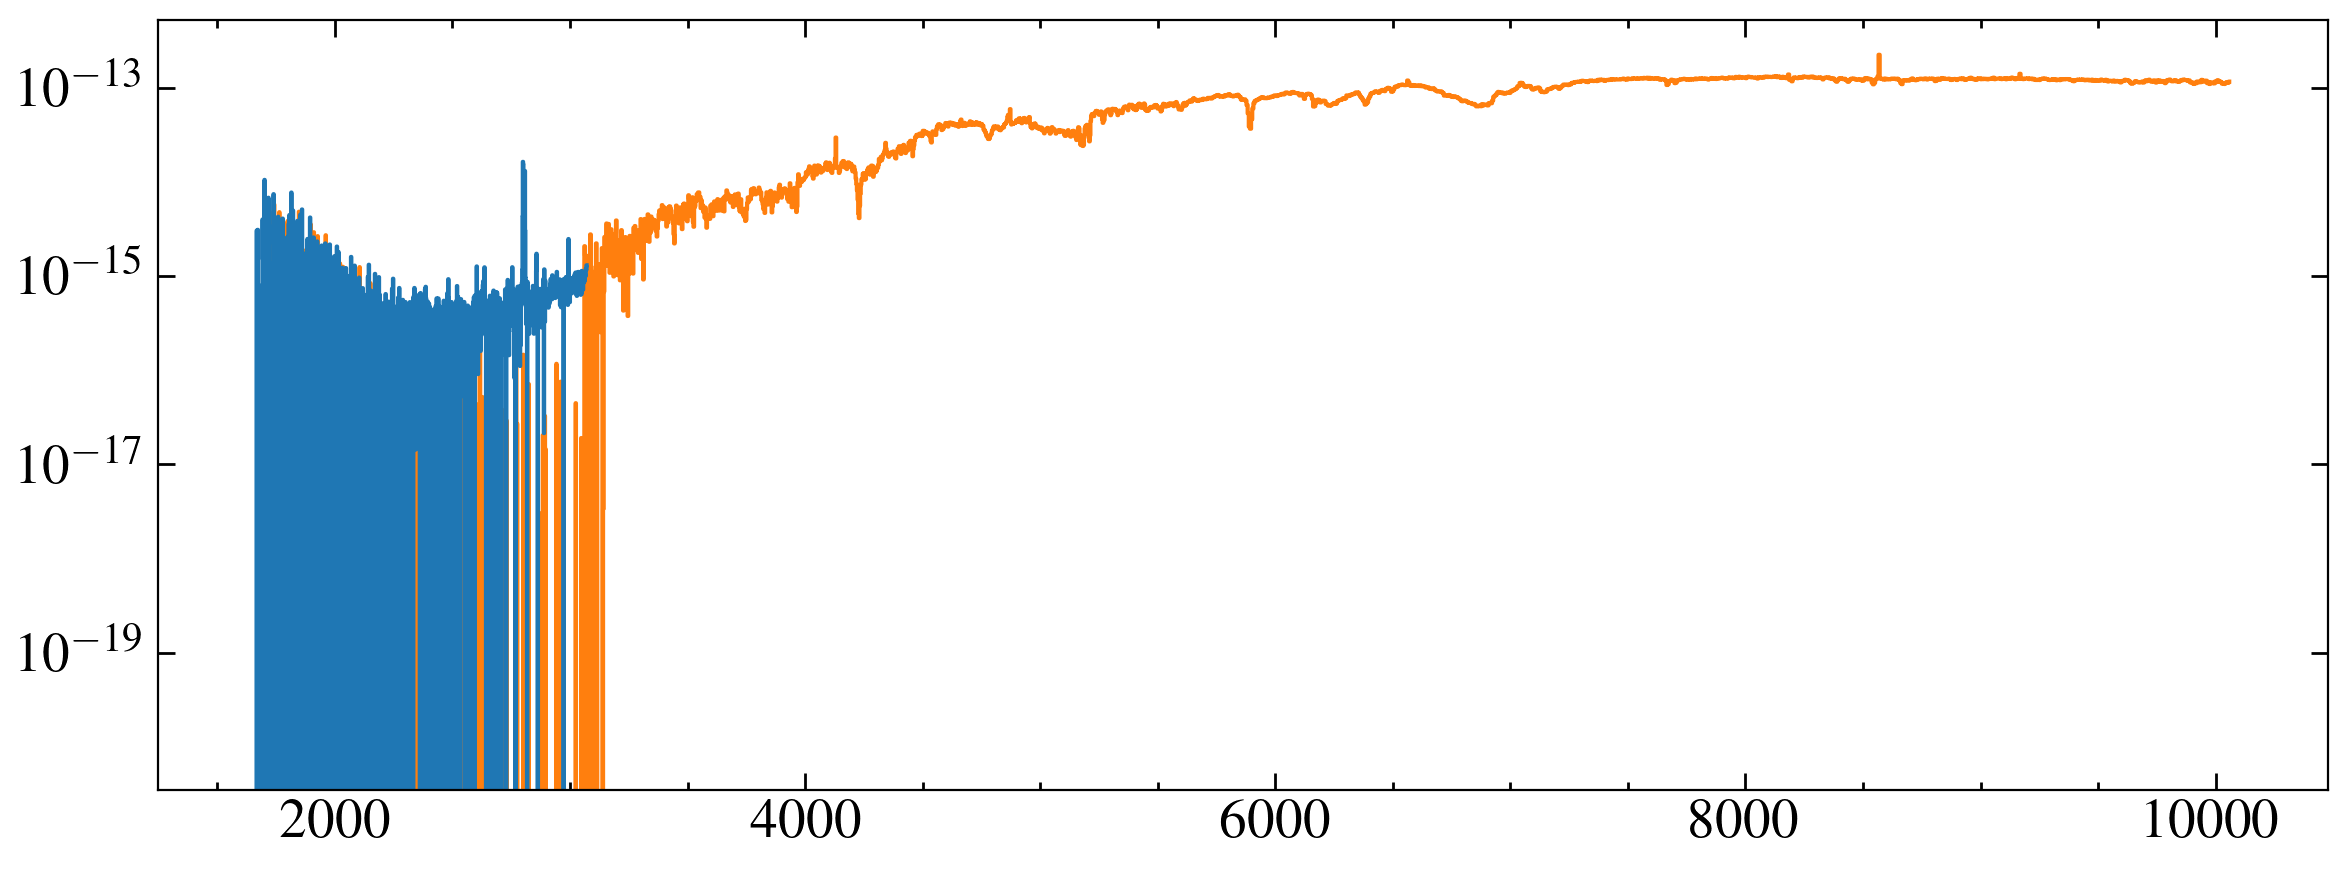

In [36]:
sw, sf, se = lowdata['Wavelength'], lowdata['Scattered Light & Slit Offcenter Corrected'], lowdata['Error_scattered_slit']


fig, ax = plt.subplots()

ax.step(nw,nf, where='mid')
ax.step(sw,sf, where='mid', zorder=-1)

ax.set_yscale('log')

w = np.hstack((nw, sw[sw > nw[-1]]))
f = np.hstack((nf, sf[sw > nw[-1]]))
e = np.hstack((ne, se[sw > nw[-1]]))

# ax.step(w, f, where='mid')

# spec = Table([w, f, e], names=['WAVELENGTH', 'FLUX', 'ERROR'])
# spec.write('data/wolf1130_stis_fixed_v2.csv', format='csv', overwrite=True)

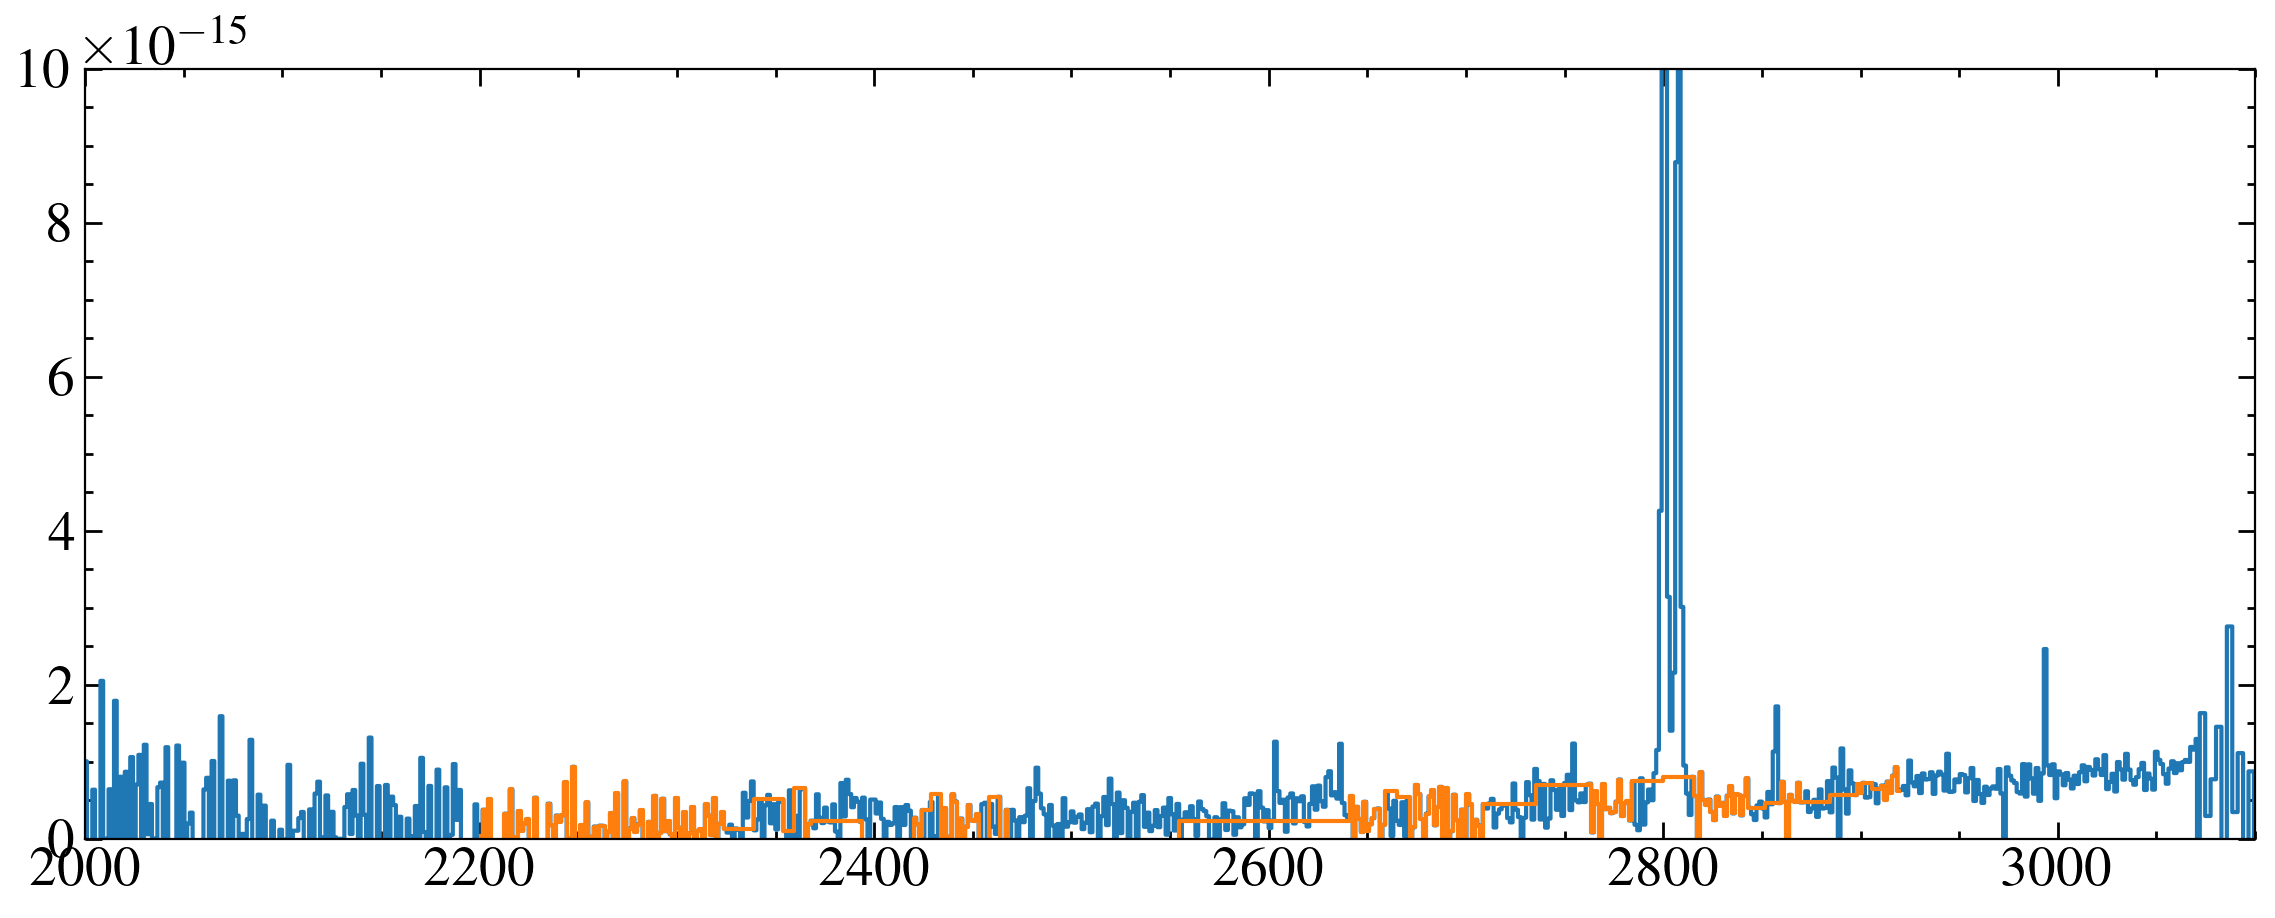

In [37]:
def mask_maker(x, pairs, include=True):
    """
    creates a mask for a spectrum that excudes between pairs from an array
    """
    b = pairs[::2]
    r = pairs[1::2]
    C = np.zeros_like(x,dtype='bool')
    for i in range(len(b)):
        C |= (x>b[i])&(x<r[i])
    if include:
        return ~C
    else:
        return C

cmaskbrs = [2200, 2325, 2353, 2356, 2364, 2369, 2418, 2425, 2432, 2455, 2463, 2470, 2640, 2660, 2670, 2710, 2761, 2785,
           2814, 2845, 2858, 2872, 2897, 2902, 2909, 2920]


fig, ax = plt.subplots()

mask = mask_maker(w, cmaskbrs, include=False)
cw, cf = w[mask], f[mask]

ax.step(w, f, where='mid')
ax.step(cw, cf, where ='mid')

# ax.set_yscale('log')
ax.set_ylim(0, 1e-14)
ax.set_xlim(2000, 3100)

b = cmaskbrs[::2]
r = cmaskbrs[1::2]

# pairs = Table([b, r], names=['W0', 'W1'])
# pairs.write('gj207d1_continuum_v01.csv', format='csv', overwrite=True)

X-rays etc.

In [38]:
swiftlc = Table.read('/media/david/2tb_ext_hd/hddata/carmenes_binary/wolf1130/swift/xrt/lc/USERPROD_251678/lc/curve.qdp')
# swiftlc
xtime = swiftlc['col1']
xcounts = swiftlc['col2']
xcounts_e = np.array([swiftlc['col2_perr'], abs(swiftlc['col2_nerr'])])

<ErrorbarContainer object of 3 artists>

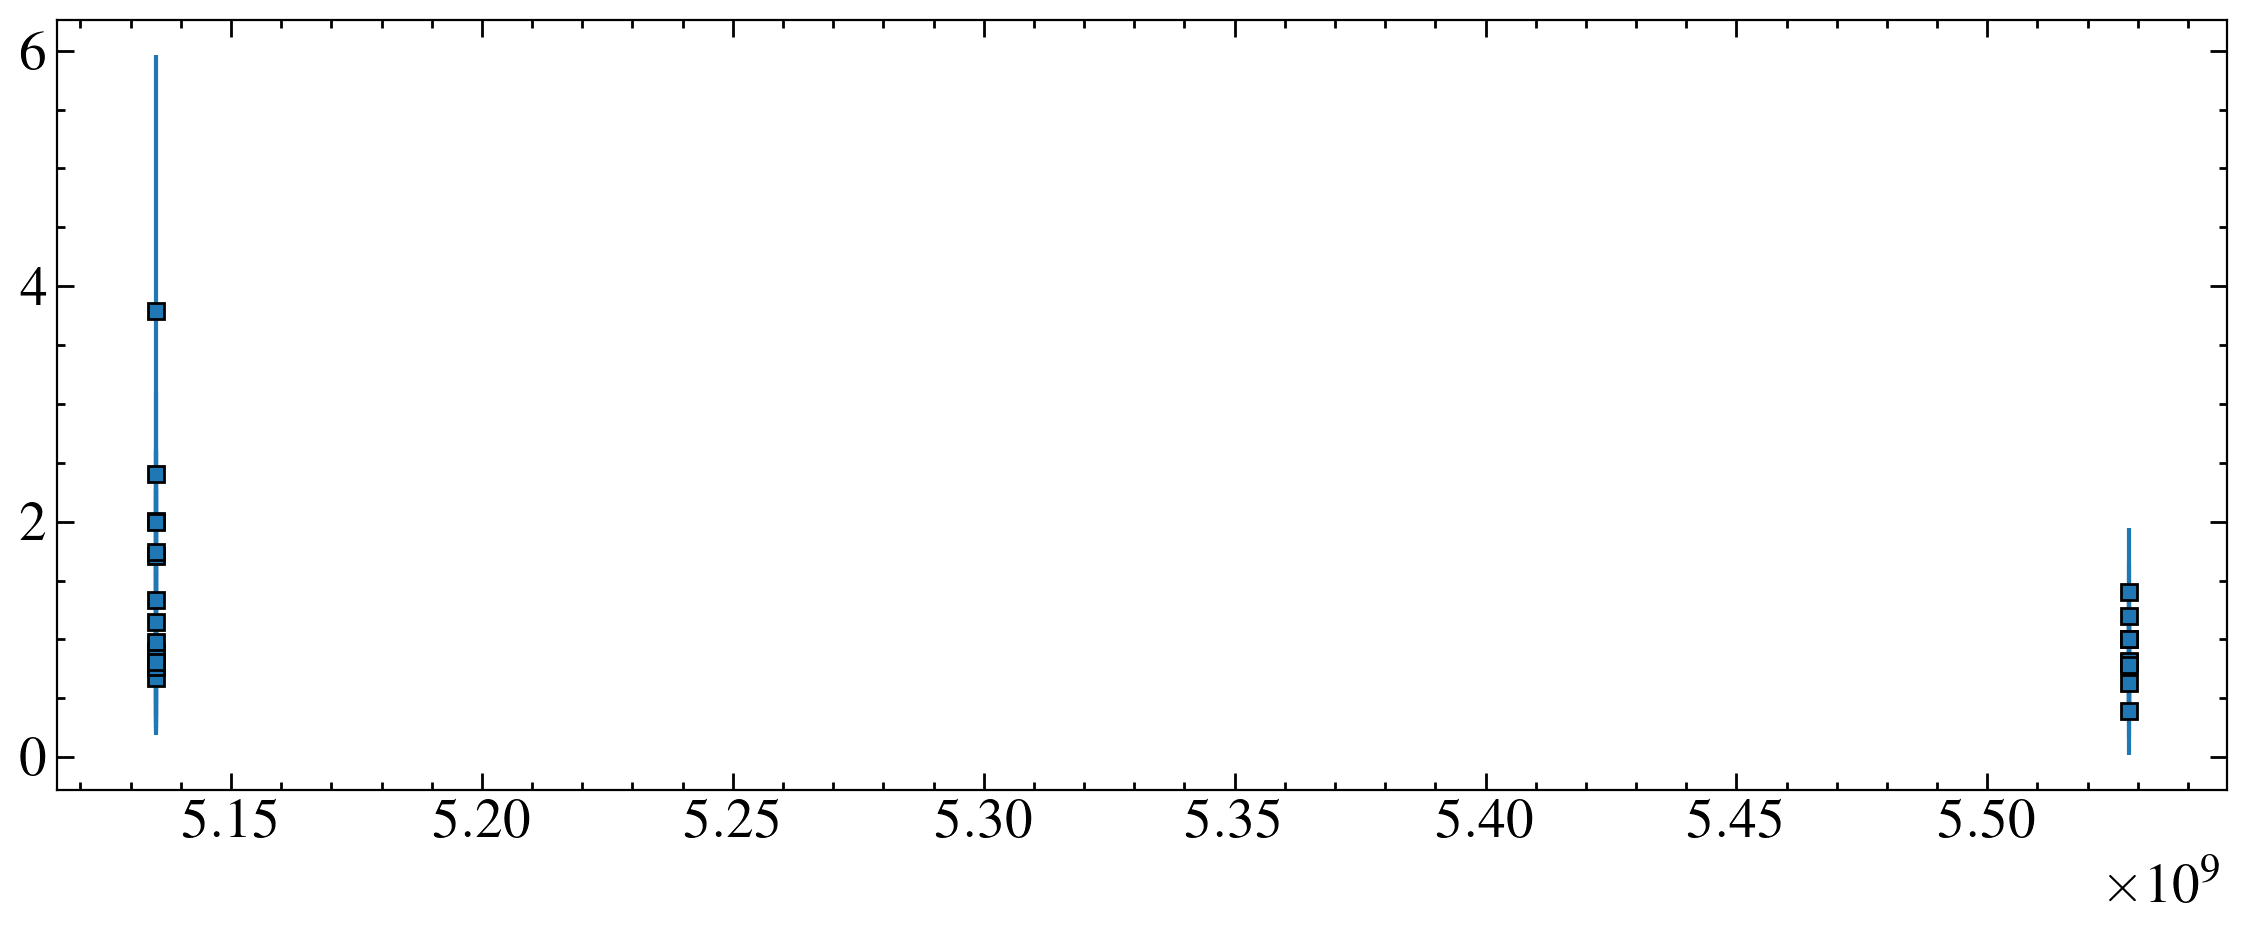

In [42]:
#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400
xref = 650034242.0006 #different for X-ray

fig, ax = plt.subplots()
xmask = xtime > 0 #just this observation
xt = xtime[xmask] + xref + ref_sec
xf, xe = xcounts[xmask] / np.median(xcounts[xmask]), np.array([xcounts_e[0][xmask] / np.median(xcounts[xmask]), xcounts_e[1][xmask] / np.median(xcounts[xmask])])
ax.errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')


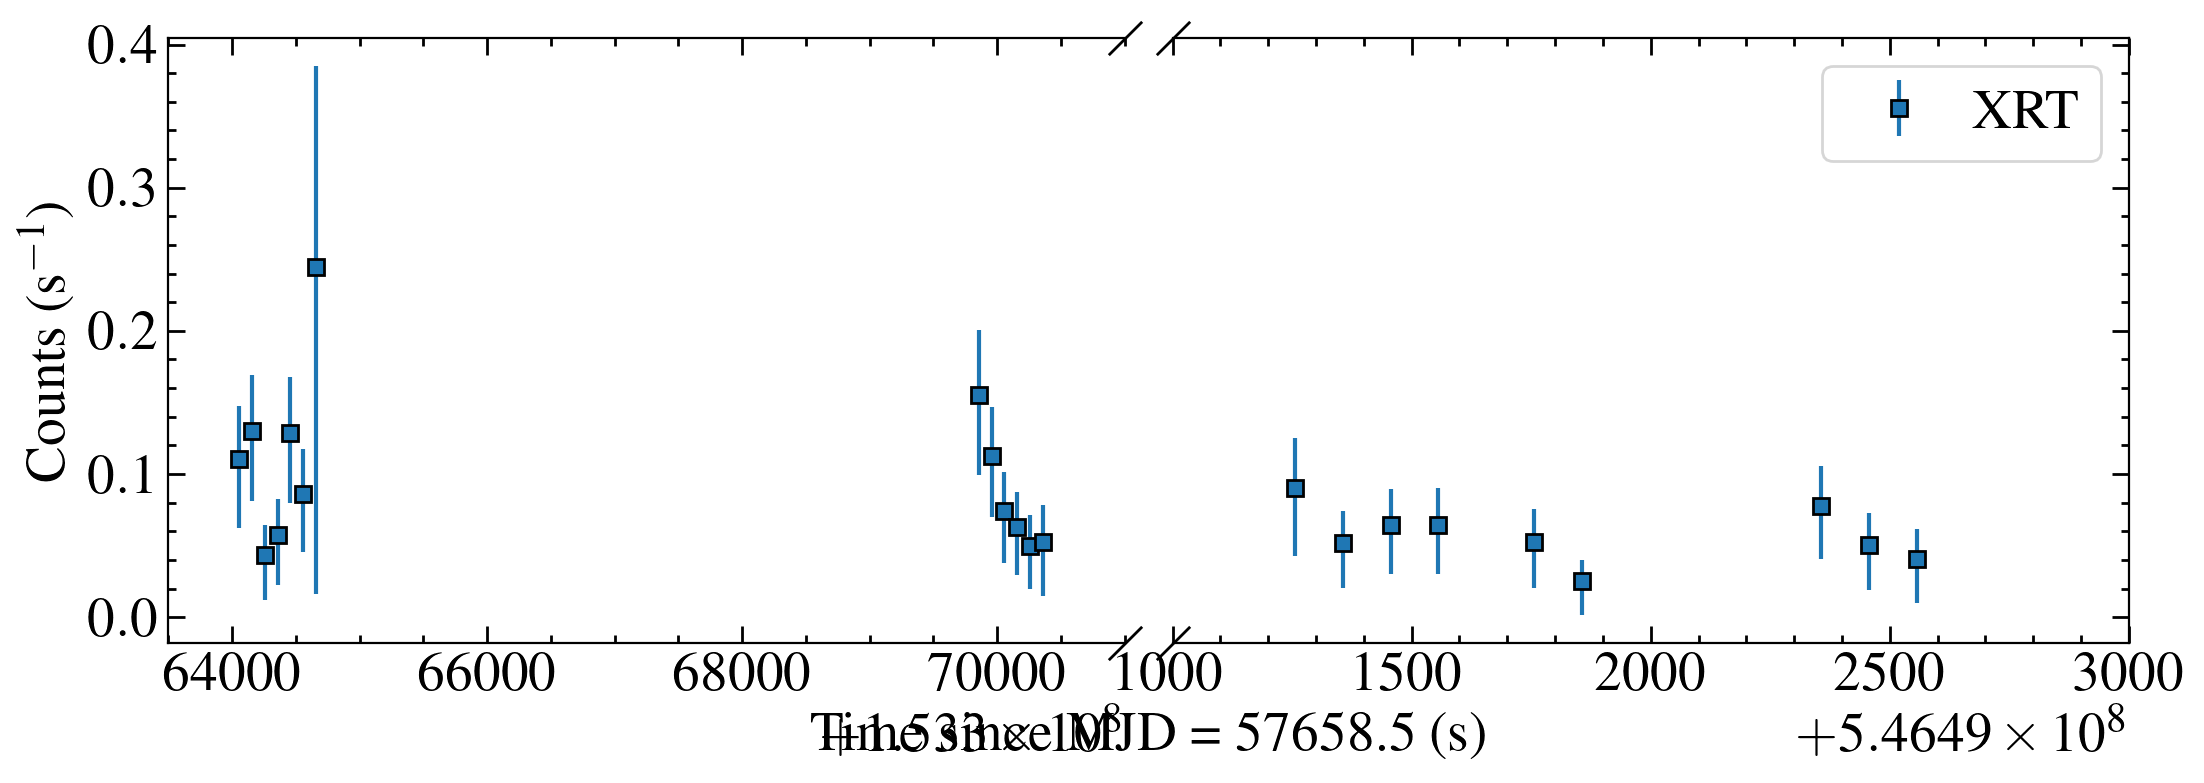

In [63]:
fig, axes = plt.subplots(ncols=2, sharey = True, figsize=(12, 5)) 

#swift reference times
ref_mjd = 51910
ref_sec = ref_mjd * 86400

xref = 650034242.0006 #different for X-ray

mjd0 = 57658.5 #day of first XRT observation

# for i,  lc in enumerate(lcs[::-1][1]):
for j in range(len(axes)):

   
    #xrt
    # xmask = xtime > 0 #just this observation
    xt = xtime + xref + ref_sec- mjd0 *86400
    xf, xe = xcounts, np.array([xcounts_e[0], xcounts_e[1] ]) 
    axes[j].errorbar(xt, xf, yerr = xe, marker='s', ls='none', markeredgecolor='k', label=r'XRT')
    
    

# axes[0].set_ylim(0.31, 1.99) # should only need to set the ylims on the first subplot because sharey = True
axes[0].set_xlim(1.533635e8, 1.53371e8) #setting up the ranges that the plots will cover. One row per subplot
axes[1].set_xlim(5.46491e8, 5.46493e8)

# axes[0].legend(frameon=True, loc=3)
axes[1].legend(frameon=True, loc=1)

"""
Everything between here and the next docstring should work regardless of how many subplots you have
"""

#setting up the slanted lines
d = 1.  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)

for i in range(len(axes)):
    
    # axes[i].scatter(xs, ys, edgecolor='k') #add the points to each plot
    
    if i > 0: #turn off yticks for everything except the first plot
        axes[i].yaxis.set_tick_params(labelleft=False)
      
    if i != len(axes)-1: #do these things for every subplot exept the last
        axes[i].spines.right.set_visible(False) #turn off right ax
        axes[i].tick_params(right = False, which='both') #turn off right ticks
        axes[i].plot([1, 1], [0, 1], transform=axes[i].transAxes, **kwargs) #add the slanted line to the right corners
   
    if i > 0: #do these things for every subplot except the first
        axes[i].spines.left.set_visible(False) #as for the last loop but for the left
        axes[i].tick_params(left = False, which='both')
        axes[i].plot([0, 0], [1, 0], transform=axes[i].transAxes, **kwargs)
        
"""
Just the axes labels beyond this.
"""    
#add a frame that goes around all the subplots to add the labels       
bigax = fig.add_subplot(111, frame_on=False)
bigax.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False, which='both')
bigax.set_ylabel('Counts (s$^{-1}$)') #change labelpad if the label is overlapping the tick labels
bigax.set_xlabel('Time since MJD = {} (s)'.format(mjd0))
# bigax.set_title('Example plot with split x axis', pad =15) 

fig.tight_layout()
fig.subplots_adjust(wspace=0.05) #change the gap in between the subplots

# fig.savefig('plots/g207d1_swift_lcs.pdf')


Ok, looks like it did a flare in the first observation. So use the second for the analysis.

https://www.swift.ac.uk/user_objects/tprods/USERPROD_251678/spec/index.php

Fairly different results from the online XRT tool and XSPEC, guess I have to fit them all separatly when I finish. But it shouldn't change the overall result, use the xrt result for now.

In [64]:
(4.4+2.3)/2

3.35

In [65]:
prot = 0.49670419 *u.d
# r0 
vmag = 11.85 #m+18
ksmag = 8.113 #simbad
# log τ = 0.64+0.10−0.12 + 0.25+0.08−0.07 (V − Ks ), wright+18
logtau = 0.64 + 0.25*(vmag -ksmag)
Ro = prot/ 10**logtau
teff = 3530*u.K
Rstar = 0.289*u.Rsun
Lstar = (const.sigma_sb * 4* np.pi * (Rstar.to(u.m))**2 * teff**4).to(u.erg/u.s)
dstar = 16.69 *u.pc
fx, fxe = 9.7e-13, 3.35e-13 # 2nd observation 
Lx = fx*(u.erg/u.s/u.cm**2) * 4*np.pi*(dstar.to(u.cm))**2
print(Lx, Lx/Lstar, Ro)

3.2329230085302776e+28 erg / s 0.0007228284664971453 0.013238775682293903 d


In [67]:
xpath = '/media/david/2tb_ext_hd/hddata/carmenes_binary/xraycat/'
xraycat = fits.open('{}J_ApJ_743_48_catalog.dat.fits'.format(xpath))
xraydata = xraycat[1].data

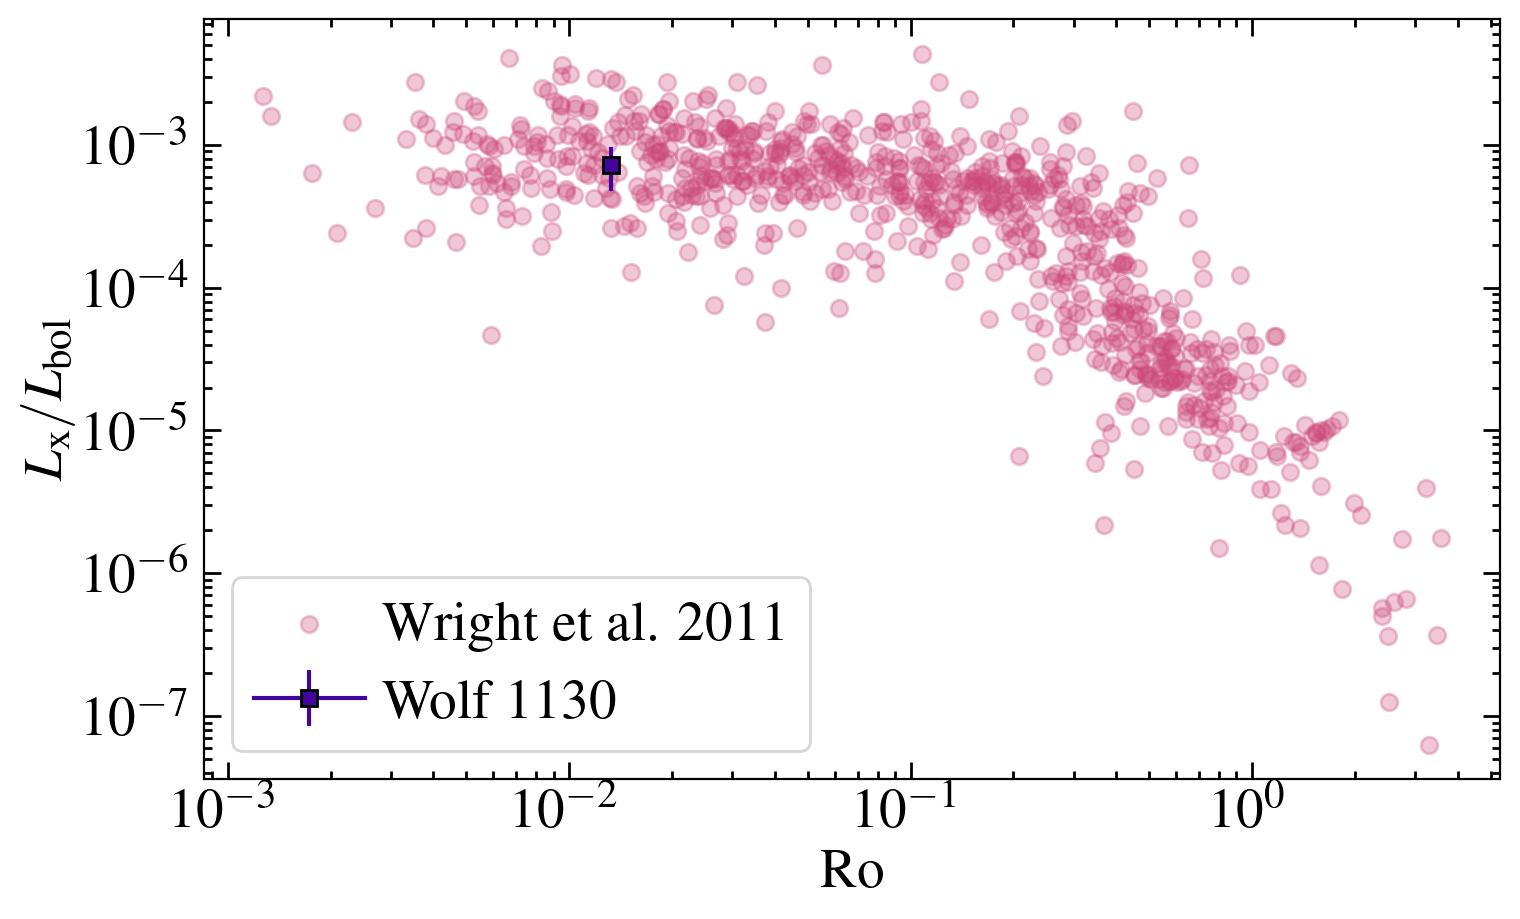

In [69]:
fig, ax = plt.subplots(figsize=(8,5))

prots = xraydata['Prot']
vks = xraydata['V-K']
ros = prots / 10**(0.64 + 0.25*vks)

ax.errorbar(Ro, Lx/Lstar, yerr=((fxe/fx) * (Lx/Lstar)), marker = 's', label ='Wolf 1130', zorder=10, markeredgecolor='k', color=plt.cm.plasma(0.1))
    
ax.scatter(ros, 10**xraydata['Lx/bol'], marker='o', alpha=0.3, label='Wright et al. 2011', color=plt.cm.plasma(0.5))
ax.set_xscale('log')
ax.set_yscale('log')
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=True)

# ax.set_xlim(0.15, 55)

# plt.legend()
# ax.set_xlabel('$P_{\mathrm{orb}}$ (d)')
ax.set_xlabel('Ro')
ax.set_ylabel(r'$L_{\mathrm{x}}/L_{\mathrm{bol}}$')
fig.tight_layout()

Right on the money